# Physionet 2012 Data Extraction RTSGAN Format

### Plan
* Static data extraction and filtering,
* Longitudinal data extraction with patient filtering,
* Data validation and consistency checks,
* Final dataset creation

### Imports and Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# import seaborn as sns
from datetime import datetime
import warnings
import glob
warnings.filterwarnings('ignore')

### Utility Functions

In [2]:
def normalize(x):
    """Normalize x to have mean 0 and std 1

    Parameters
    ----------
    x : `np.ndarray`, shape=(n, d)
        A time-independent features matrix

    Returns
    -------
    x_norm : `np.ndarray`, shape=(n, d)
        The corresponding normilized matrix with mean 0 and std 1
    """
    mean = x.mean(axis=0)
    std = x.std(axis=0)
    x_norm = (x - mean) / std

    return x_norm

def load_patient_txt_to_dataframe(filepath):
    """
    Load a patient text file into a pandas DataFrame and pivot it to a wide format.
    The input file is expected to have columns: Time, Parameter, Value.
    The function will aggregate duplicate Time/Parameter pairs by taking the mean of their values.
    The resulting DataFrame will have Time as the index and Parameters as columns.

    Parameters
    ----------
    filepath : str
        Path to the patient text file

    Returns
    -------
    df_pivot : `pd.DataFrame`
        DataFrame with Time as index and Parameters as columns
            
    """
    df_raw = pd.read_csv(filepath)
    # Optional: convert Value column to numeric (might be needed)
    df_raw['Value'] = pd.to_numeric(df_raw['Value'], errors='coerce')
    # Remove duplicates by aggregating (e.g., taking the mean for same Time/Parameter)
    df_agg = df_raw.groupby(['Time', 'Parameter'], as_index=False).agg({'Value': 'mean'})
    # Pivot to wide format
    df_pivot = df_agg.pivot(index='Time', columns='Parameter', values='Value')
    # Reset the index to make Time a column again
    df_pivot = df_pivot.reset_index()
    return df_pivot

def load_patient_txt_to_dataframe_bis(filepath):
    """
    Load a patient text file into a pandas DataFrame and pivot it to a wide format.
    The input file is expected to have columns: Time, Parameter, Value.
    The function will aggregate duplicate Time/Parameter pairs by taking the mean of their values.
    The resulting DataFrame will have Time as the first column and Parameters as other columns.

    Parameters
    ----------
    filepath : str
        Path to the patient text file

    Returns
    -------
    df_pivot : `pd.DataFrame`
        DataFrame with Time as first column and Parameters as other columns
            
    """
    df_raw = pd.read_csv(filepath)
    # Optional: convert Value column to numeric (might be needed)
    df_raw['Value'] = pd.to_numeric(df_raw['Value'], errors='coerce')
    # Remove duplicates by aggregating (e.g., taking the mean for same Time/Parameter)
    df_agg = df_raw.groupby(['Time', 'Parameter'], as_index=False).agg({'Value': 'mean'})
    # Pivot to wide format
    df_pivot = df_agg.pivot(index='Time', columns='Parameter', values='Value')
    # Reset the index to make Time a column again
    df_pivot = df_pivot.reset_index()
    # Clean up any index names that might have been created
    df_pivot.columns.name = None  # Remove columns name
    df_pivot.index.name = None    # Remove index name
    
    # Ensure Time is the first column and clean up column names
    if 'Time' in df_pivot.columns:
        # Reorder columns to put Time first
        cols = ['Time'] + [col for col in df_pivot.columns if col != 'Time']
        df_pivot = df_pivot[cols]
    
    # Clean up any column names that might have unwanted prefixes
    # This handles cases where pivot creates column names like "Parameter_Value"
    clean_columns = []
    for col in df_pivot.columns:
        if col == 'Time':
            clean_columns.append(col)
        else:
            # Remove any prefixes that might have been added
            clean_col = col.replace('Parameter_', '').replace('Value_', '')
            clean_columns.append(clean_col)
    df_pivot.columns = clean_columns
    
    return df_pivot

def validate_patient_consistency(static_patients, long_patients, stage_name):
    """Validate patient consistency between datasets"""
    print(f"\n=== {stage_name} ===")
    print(f"Static patients: {len(static_patients)}")
    print(f"Longitudinal patients: {len(long_patients)}")
    
    # Check for patients in longitudinal but not in static
    extra_in_long = set(long_patients) - set(static_patients)
    if extra_in_long:
        print(f"⚠️  {len(extra_in_long)} patients in longitudinal data but not in static data")
        
    # Check for patients in static but not in longitudinal
    missing_in_long = set(static_patients) - set(long_patients)
    if missing_in_long:
        print(f"⚠️  {len(missing_in_long)} patients in static data but not in longitudinal data")
        
    # Common patients
    common_patients = set(static_patients) & set(long_patients)
    print(f"✅ Common patients: {len(common_patients)}")
    
    return list(common_patients)

### Configuration

In [3]:
# Get a list of all the csv files
base_path = '/path/to/Documents/physionet.org/files/challenge-2012/1.0.0/'

# Load all .psv files from both training_setA and training_setB
csv_files_A = glob.glob(f'{base_path}/set-a/*.txt')
# csv_files_B = glob.glob(f'{base_path}/set-b/*.txt')

# Combine both sets
csv_files = csv_files_A # + csv_files_B

### Load and Process Physionet Data

In [4]:
i = 0
df_patients = []
df_parameters = []
lenghts = []

for file in csv_files:
    df = load_patient_txt_to_dataframe_bis(file)
    
    # # Converts to timedelta format
    # df['Time'] = pd.to_timedelta(df['Time'] + ':00')
    # # Then extract float values, for example, in minutes
    # df['Time'] = df['Time'].dt.total_seconds() / (60*60)

    # Converts to timedelta format
    df['Time'] = pd.to_timedelta(df['Time'] + ':00')
    # Convert to days (more explicit)
    seconds_per_day = 24 * 60 * 60  # 24 hours * 60 minutes * 60 seconds
    df['Time'] = df['Time'].dt.total_seconds() / seconds_per_day

    if i == 0:
        display(df.head())
        i += 1
   
    # Here I keep only the patients who have at least 5 visits time points
    if len(df['Time']) >= 5:  
        # Reset index to avoid any index becoming a column later
        df = df.reset_index(drop=True)
        
        lenghts.append(len(df['Time']))
        df_patients.append(df)
        df_parameters.append(list(df.columns))

df_parameters_concat = np.concatenate(df_parameters).squeeze()
unique_parameters, indices = np.unique(df_parameters_concat, return_index=True)
# Sort the unique values by the order of first appearance
unique_in_order = unique_parameters[np.argsort(indices)]
print(f"Number of variables: {len(unique_in_order)}")
print(f"Variables: {unique_in_order}")

lengths = np.array(lenghts)
print(f"Number of time points per patient: min {lengths.min()}, max {lengths.max()}, mean {lengths.mean()}, std {lengths.std()}, median {np.median(lengths)}")
print(f"Number of patients: {len(df_patients)}")

,Time,Age,BUN,Creatinine,GCS,Gender,Glucose,HCO3,HCT,HR,...,NISysABP,Na,Platelets,RecordID,RespRate,Temp,TroponinT,Urine,WBC,Weight
0,0.000000,35.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,132592.0,NaN,NaN,NaN,NaN,NaN,71.8
1,0.055556,NaN,NaN,NaN,15.0,NaN,NaN,NaN,NaN,112.0,...,120.0,NaN,NaN,NaN,22.0,36.6,NaN,NaN,NaN,71.8
2,0.097222,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,113.0,...,124.0,NaN,NaN,NaN,21.0,NaN,NaN,120.0,NaN,71.8
3,0.108333,NaN,68.0,2.3,NaN,NaN,603.0,11.0,25.5,NaN,...,NaN,140.0,287.0,NaN,NaN,NaN,0.15,NaN,15.3,NaN
4,0.138889,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,112.0,...,118.0,NaN,NaN,NaN,24.0,NaN,NaN,60.0,NaN,71.8


Number of variables: 43
Variables: ['Time' 'Age' 'BUN' 'Creatinine' 'GCS' 'Gender' 'Glucose' 'HCO3' 'HCT'
 'HR' 'Height' 'ICUType' 'K' 'Mg' 'NIDiasABP' 'NIMAP' 'NISysABP' 'Na'
 'Platelets' 'RecordID' 'RespRate' 'Temp' 'TroponinT' 'Urine' 'WBC'
 'Weight' 'ALP' 'ALT' 'AST' 'Albumin' 'Bilirubin' 'FiO2' 'MechVent'
 'PaCO2' 'PaO2' 'pH' 'DiasABP' 'MAP' 'SaO2' 'SysABP' 'Lactate'
 'Cholesterol' 'TroponinI']
Number of time points per patient: min 5, max 203, mean 75.08732747804267, std 22.754527780506393, median 72.0
Number of patients: 3985


In [5]:
df_patients[0].head()

,Time,Age,BUN,Creatinine,GCS,Gender,Glucose,HCO3,HCT,HR,...,NISysABP,Na,Platelets,RecordID,RespRate,Temp,TroponinT,Urine,WBC,Weight
0,0.000000,35.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,132592.0,NaN,NaN,NaN,NaN,NaN,71.8
1,0.055556,NaN,NaN,NaN,15.0,NaN,NaN,NaN,NaN,112.0,...,120.0,NaN,NaN,NaN,22.0,36.6,NaN,NaN,NaN,71.8
2,0.097222,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,113.0,...,124.0,NaN,NaN,NaN,21.0,NaN,NaN,120.0,NaN,71.8
3,0.108333,NaN,68.0,2.3,NaN,NaN,603.0,11.0,25.5,NaN,...,NaN,140.0,287.0,NaN,NaN,NaN,0.15,NaN,15.3,NaN
4,0.138889,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,112.0,...,118.0,NaN,NaN,NaN,24.0,NaN,NaN,60.0,NaN,71.8


### Analysis of Missingness

In [6]:
all_missing_sample_df = pd.DataFrame(True, index=range(len(df_patients)), columns=unique_in_order)
missing_value_df = pd.DataFrame(1.0, index=range(len(df_patients)), columns=unique_in_order)
i = 0
for df in df_patients:
    is_all_missing = df.isnull().min()
    percent_missing = df.isnull().mean()
    missing_value_df.iloc[i] = percent_missing.reindex(missing_value_df.columns).fillna(1.0)
    all_missing_sample_df.iloc[i] = is_all_missing.reindex(all_missing_sample_df.columns).fillna(True).astype(bool) # (True/False)
    i += 1
    
missing_stat_df = pd.concat([pd.DataFrame(all_missing_sample_df.mean(), columns=["all_missing"]),
                             pd.DataFrame(missing_value_df.mean(), columns=["level_missing"])], axis=1)
display(missing_stat_df)

,all_missing,level_missing
Time,0.000000,0.000000
Age,0.000000,0.984472
BUN,0.014806,0.948126
Creatinine,0.014806,0.947897
GCS,0.012296,0.781578
Gender,0.000000,0.984472
Glucose,0.027102,0.950614
HCO3,0.017817,0.949001
HCT,0.014806,0.934125
HR,0.012296,0.230936


### Identify Longitudinal vs Static Variables

In [7]:
features_static_names = ["Age", "Gender", "Height", "ICUType", "Weight"]
unselected_features_static_names = ["RecordID"]
# survival_indicator_names = ["SepsisLabel"]
time_measurment_names = ["Time"]

"""
    Selection of static features: the ones which are available for at least 40% of the patients,
    and missing in at least 70% of the time steps so likely recorded just once, as a static or baseline variable.
    (These percentages can be changed and adapted).
"""
features_convert_static = missing_stat_df[
    (~missing_stat_df.index.isin(unselected_features_static_names) &
     ~missing_stat_df.index.isin(features_static_names) &
     ~missing_stat_df.index.isin(time_measurment_names) &
     (missing_stat_df.all_missing <= .5)  & # available for ≥50% of patients
     (missing_stat_df.level_missing >= .9) # missing in ≥90% of time steps --> likely recorded just once.
     )].index.values.tolist()
print('features_convert_static', features_convert_static)


"""
    Selection of longitudinal features: the ones which are available for at least 40% of the patients,
    and actually observed at, at least, 30% of the visits time.
    (These percentages can be changed and adapted).
    The features which are not selected as static features, and not selected as unselected features,
    are considered as longitudinal features.
"""
features_timedep_names = missing_stat_df[
    ((~missing_stat_df.index.isin(features_convert_static)) &
        ~missing_stat_df.index.isin(unselected_features_static_names) &
        ~missing_stat_df.index.isin(features_static_names) &
        # ~missing_stat_df.index.isin(survival_indicator_names) &
        ~missing_stat_df.index.isin(time_measurment_names) &
        (missing_stat_df.all_missing < .6) &
        (missing_stat_df.level_missing < .9))].index.values.tolist()
print('features_timedep_names', features_timedep_names)

features_timeindep_names = features_static_names + features_convert_static
print('features_timeindep_names', features_timeindep_names)

features_convert_static ['BUN', 'Creatinine', 'Glucose', 'HCO3', 'HCT', 'K', 'Mg', 'Na', 'Platelets', 'WBC', 'MechVent', 'PaCO2', 'PaO2', 'pH', 'Lactate']
features_timedep_names ['GCS', 'HR', 'NIDiasABP', 'NIMAP', 'NISysABP', 'Temp', 'Urine', 'FiO2', 'DiasABP', 'MAP', 'SysABP']
features_timeindep_names ['Age', 'Gender', 'Height', 'ICUType', 'Weight', 'BUN', 'Creatinine', 'Glucose', 'HCO3', 'HCT', 'K', 'Mg', 'Na', 'Platelets', 'WBC', 'MechVent', 'PaCO2', 'PaO2', 'pH', 'Lactate']


### Process Static Data

In [8]:
data_static = []

for patient_id, df in enumerate(df_patients):
    missing_cols = [col for col in features_timeindep_names if col not in df.columns]
    # print(missing_cols)
    for col in missing_cols:
        df[col] = np.nan
    df[features_static_names] = df[features_static_names].replace(-1, np.nan)
    row = df[features_timeindep_names].median(skipna=True)
    
    # Create a new Series with PATIENT_ID first
    row_dict = {'PATIENT_ID': int(patient_id)}
    row_dict.update(row.to_dict())
    row_with_id = pd.Series(row_dict)
    
    data_static.append(row_with_id)

df_static = pd.DataFrame(data_static)

print(f"Shape of static data: {df_static.shape}")
print(f"Columns: {list(df_static.columns)}")
print(f"PATIENT_ID range: {df_static['PATIENT_ID'].min()} to {df_static['PATIENT_ID'].max()}")
df_static.head()

Shape of static data: (3985, 21)
Columns: ['PATIENT_ID', 'Age', 'Gender', 'Height', 'ICUType', 'Weight', 'BUN', 'Creatinine', 'Glucose', 'HCO3', 'HCT', 'K', 'Mg', 'Na', 'Platelets', 'WBC', 'MechVent', 'PaCO2', 'PaO2', 'pH', 'Lactate']
PATIENT_ID range: 0.0 to 3984.0


,PATIENT_ID,Age,Gender,Height,ICUType,Weight,BUN,Creatinine,Glucose,HCO3,...,K,Mg,Na,Platelets,WBC,MechVent,PaCO2,PaO2,pH,Lactate
0,0.0,35.0,0.0,NaN,3.0,71.8,55.0,1.7,123.0,16.5,...,4.45,2.00,143.5,287.0,13.90,NaN,NaN,NaN,NaN,NaN
1,1.0,42.0,1.0,NaN,3.0,138.1,9.0,0.7,235.0,27.0,...,3.50,2.05,135.5,160.0,17.85,1.0,43.5,84.0,7.43,NaN
2,2.0,61.0,1.0,188.0,2.0,80.0,11.0,0.8,130.0,23.0,...,4.60,2.00,138.0,206.5,17.10,1.0,44.0,156.0,7.35,NaN
3,3.0,53.0,0.0,170.2,4.0,96.1,13.5,0.7,115.0,27.0,...,4.10,2.20,142.0,256.5,10.70,NaN,NaN,NaN,NaN,2.0
4,4.0,46.0,1.0,NaN,3.0,82.0,17.0,1.0,199.0,25.0,...,3.80,1.90,137.0,205.0,10.85,NaN,NaN,NaN,NaN,1.4


In [9]:
df_static.drop(columns=['MechVent'], inplace=True)
df_static.head()

,PATIENT_ID,Age,Gender,Height,ICUType,Weight,BUN,Creatinine,Glucose,HCO3,HCT,K,Mg,Na,Platelets,WBC,PaCO2,PaO2,pH,Lactate
0,0.0,35.0,0.0,NaN,3.0,71.8,55.0,1.7,123.0,16.5,24.05,4.45,2.00,143.5,287.0,13.90,NaN,NaN,NaN,NaN
1,1.0,42.0,1.0,NaN,3.0,138.1,9.0,0.7,235.0,27.0,41.40,3.50,2.05,135.5,160.0,17.85,43.5,84.0,7.43,NaN
2,2.0,61.0,1.0,188.0,2.0,80.0,11.0,0.8,130.0,23.0,27.30,4.60,2.00,138.0,206.5,17.10,44.0,156.0,7.35,NaN
3,3.0,53.0,0.0,170.2,4.0,96.1,13.5,0.7,115.0,27.0,35.90,4.10,2.20,142.0,256.5,10.70,NaN,NaN,NaN,2.0
4,4.0,46.0,1.0,NaN,3.0,82.0,17.0,1.0,199.0,25.0,29.85,3.80,1.90,137.0,205.0,10.85,NaN,NaN,NaN,1.4


### Define Static Data Types

In [10]:
# Example types: 'real', 'cat', 'pos', etc.
# You might already know these from metadata or define them manually
static_types = {
    "Age": ("real", 1, 1),
    "Gender": ("cat", 1, 2),
    "Height": ("real", 1, 1),
    "ICUType": ("cat", 1, 4), 
    "Weight": ("real", 1, 1)
    # Add more based on your `features_convert_static`
}

for var in features_convert_static:
    if var not in static_types:
        static_types[var] = ("real", 1, 1)  # default, update if needed

print("Static data types defined")
print(f"Number of static variables: {len(static_types)}")
print(static_types)

Static data types defined
Number of static variables: 20
{'Age': ('real', 1, 1), 'Gender': ('cat', 1, 2), 'Height': ('real', 1, 1), 'ICUType': ('cat', 1, 4), 'Weight': ('real', 1, 1), 'BUN': ('real', 1, 1), 'Creatinine': ('real', 1, 1), 'Glucose': ('real', 1, 1), 'HCO3': ('real', 1, 1), 'HCT': ('real', 1, 1), 'K': ('real', 1, 1), 'Mg': ('real', 1, 1), 'Na': ('real', 1, 1), 'Platelets': ('real', 1, 1), 'WBC': ('real', 1, 1), 'MechVent': ('real', 1, 1), 'PaCO2': ('real', 1, 1), 'PaO2': ('real', 1, 1), 'pH': ('real', 1, 1), 'Lactate': ('real', 1, 1)}


### Process Longitudinal Data

In [11]:
# Step 2: Create aligned 3D array with patient IDs
long_data = []
features_long = time_measurment_names + features_timedep_names

for patient_id, df in enumerate(df_patients):  # Use enumerate to get patient ID
    missing_cols = [col for col in features_long if col not in df.columns]
    # print(missing_cols)
    for col in missing_cols:
        df[col] = np.nan
    df_long = df[features_long]
    
    # Add patient ID column
    df_long['PATIENT_ID'] = patient_id  # Add patient ID (0, 1, 2, ...)

    # # Drop initial rows where all time-dependent features are NaN
    # mask_not_all_nan = df_long[features_long].notna().any(axis=1)
    # if mask_not_all_nan.any():
    #     first_valid_index = mask_not_all_nan.idxmax()
    #     df_long = df_long.loc[first_valid_index:]
        
    long_data.append(df_long)

df_long = pd.concat(long_data)
# Reorder columns to put PATIENT_ID first
df_long = df_long[['PATIENT_ID'] + [col for col in df_long.columns if col != 'PATIENT_ID']]

print(f"Shape of long data: {df_long.shape}")
print(f"Number of unique patients: {df_long['PATIENT_ID'].nunique()}")
print(f"Patient ID range: {df_long['PATIENT_ID'].min()} to {df_long['PATIENT_ID'].max()}")
df_long.head()

Shape of long data: (299223, 13)
Number of unique patients: 3985
Patient ID range: 0 to 3984


,PATIENT_ID,Time,GCS,HR,NIDiasABP,NIMAP,NISysABP,Temp,Urine,FiO2,DiasABP,MAP,SysABP
0,0,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0,0.055556,15.0,112.0,43.0,68.67,120.0,36.6,NaN,NaN,NaN,NaN,NaN
2,0,0.097222,NaN,113.0,53.0,76.67,124.0,NaN,120.0,NaN,NaN,NaN,NaN
3,0,0.108333,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0,0.138889,NaN,112.0,48.0,71.33,118.0,NaN,60.0,NaN,NaN,NaN,NaN


In [12]:
zero_visits = df_long[df_long['Time'] == 0]
print(f"Total visits at day 0: {len(zero_visits)}")

Total visits at day 0: 3985


In [13]:
zero_visits.head(50)

,PATIENT_ID,Time,GCS,HR,NIDiasABP,NIMAP,NISysABP,Temp,Urine,FiO2,DiasABP,MAP,SysABP
0,0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0,1,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0,2,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0,3,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0,4,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0,5,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0,6,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0,7,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0,8,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0,9,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [14]:
print("=== Normalizing to First Visit ===")

df_long['Time'] = df_long.groupby('PATIENT_ID')['Time'].transform(lambda x: (x - x.min()))
# Verify normalization
zero_visits = df_long[df_long['Time'] == 0]
print(f"Patients with visits at day 0: {zero_visits['PATIENT_ID'].nunique()}")
print(f"Total visits at day 0: {len(zero_visits)}")

# Check that all patients have a day 0 visit
total_patients = df_long['PATIENT_ID'].nunique()
patients_with_zero = zero_visits['PATIENT_ID'].nunique()
print(f"All patients have day 0 visit: {total_patients == patients_with_zero}")

df_long.head()

=== Normalizing to First Visit ===
Patients with visits at day 0: 3985
Total visits at day 0: 3985
All patients have day 0 visit: True


,PATIENT_ID,Time,GCS,HR,NIDiasABP,NIMAP,NISysABP,Temp,Urine,FiO2,DiasABP,MAP,SysABP
0,0,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0,0.055556,15.0,112.0,43.0,68.67,120.0,36.6,NaN,NaN,NaN,NaN,NaN
2,0,0.097222,NaN,113.0,53.0,76.67,124.0,NaN,120.0,NaN,NaN,NaN,NaN
3,0,0.108333,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0,0.138889,NaN,112.0,48.0,71.33,118.0,NaN,60.0,NaN,NaN,NaN,NaN


### Validate Patient Consistency

In [15]:
# Validate patient consistency
static_patients = df_static.index.tolist()
longitudinal_patients = df_long['PATIENT_ID'].unique().tolist()

common_patients = validate_patient_consistency(static_patients, longitudinal_patients, "Patient Consistency Check")

# Filter both datasets to only include common patients
df_static_final = df_static.loc[common_patients]
df_long_final = df_long[df_long['PATIENT_ID'].isin(common_patients)].copy()

print(f"\nAfter filtering:")
print(f"Static data: {len(df_static_final)} patients")
print(f"Longitudinal data: {df_long_final['PATIENT_ID'].nunique()} patients")

# Verify consistency
assert len(df_static_final) == df_long_final['PATIENT_ID'].nunique(), "Patient counts must match!"
print("✅ Patient consistency verified!")


=== Patient Consistency Check ===
Static patients: 3985
Longitudinal patients: 3985
✅ Common patients: 3985

After filtering:
Static data: 3985 patients
Longitudinal data: 3985 patients
✅ Patient consistency verified!


### Timepoints with zero information in Y were excluded

In [16]:
# 1. Définir le nombre de colonnes médicales (Features)
# On exclut les colonnes d'index comme RSUBJID et Time
medical_features = [c for c in df_long_final.columns if c not in ['PATIENT_ID', 'Time']]
n_features = len(medical_features)

# 2. Calculer le seuil (50% de présence)
# Exemple : si vous avez 30 variables, il en faut au moins 21 non-nulles
# min_info_threshold = int(0.5 * n_features)
min_info_threshold = 1

# 3. Compter les valeurs non-nulles par ligne
df_long_final['info_count'] = df_long_final[medical_features].notna().sum(axis=1)
df_long_final.head()


,PATIENT_ID,Time,GCS,HR,NIDiasABP,NIMAP,NISysABP,Temp,Urine,FiO2,DiasABP,MAP,SysABP,info_count
0,0,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
1,0,0.055556,15.0,112.0,43.0,68.67,120.0,36.6,NaN,NaN,NaN,NaN,NaN,6
2,0,0.097222,NaN,113.0,53.0,76.67,124.0,NaN,120.0,NaN,NaN,NaN,NaN,5
3,0,0.108333,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
4,0,0.138889,NaN,112.0,48.0,71.33,118.0,NaN,60.0,NaN,NaN,NaN,NaN,5


In [17]:
print(df_long_final['info_count'].unique())

[ 0  6  5  7  4  2  1  3  8  9 10 11]


In [18]:
lignes_avant = len(df_long_final)
print(f"Lignes avant filtre : {lignes_avant}")

# 4. Appliquer le filtre
df_long_final = df_long_final[df_long_final['info_count'] >= min_info_threshold].copy()
df_long_final = df_long_final.drop(columns=['info_count'])

lignes_apres = len(df_long_final)
print(f"Lignes après filtre : {lignes_apres}")
print(f"Lignes supprimées : {lignes_avant - lignes_apres}")

Lignes avant filtre : 299223
Lignes après filtre : 245319
Lignes supprimées : 53904


In [19]:
df_long_final.head(10)

,PATIENT_ID,Time,GCS,HR,NIDiasABP,NIMAP,NISysABP,Temp,Urine,FiO2,DiasABP,MAP,SysABP
1,0,0.055556,15.0,112.0,43.0,68.67,120.0,36.6,NaN,NaN,NaN,NaN,NaN
2,0,0.097222,NaN,113.0,53.0,76.67,124.0,NaN,120.0,NaN,NaN,NaN,NaN
4,0,0.138889,NaN,112.0,48.0,71.33,118.0,NaN,60.0,NaN,NaN,NaN,NaN
5,0,0.180556,NaN,113.0,59.0,81.33,126.0,NaN,60.0,NaN,NaN,NaN,NaN
6,0,0.222222,NaN,115.0,63.0,84.33,127.0,37.1,80.0,NaN,NaN,NaN,NaN
7,0,0.263889,15.0,111.0,59.0,83.67,133.0,NaN,70.0,NaN,NaN,NaN,NaN
8,0,0.305556,NaN,105.0,48.0,68.00,108.0,NaN,50.0,NaN,NaN,NaN,NaN
9,0,0.347222,NaN,105.0,53.0,71.67,109.0,NaN,40.0,NaN,NaN,NaN,NaN
10,0,0.388889,NaN,103.0,68.0,88.00,128.0,NaN,50.0,NaN,NaN,NaN,NaN
11,0,0.430556,15.0,103.0,47.0,73.33,126.0,37.0,40.0,NaN,NaN,NaN,NaN


### Exclusion of patients with less that 5 observations

In [20]:
# Check minimum time points per patient
print("=== Patient Time Points Analysis ===")
time_points_per_patient = df_long_final.groupby('PATIENT_ID').size()
print(f"Time points per patient - min: {time_points_per_patient.min()}, max: {time_points_per_patient.max()}, mean: {time_points_per_patient.mean():.1f}")

# Find patients with sufficient time points
patients_with_sufficient_time = time_points_per_patient[time_points_per_patient >= 5].index.tolist()
print(f"Patients with >=5 time points: {len(patients_with_sufficient_time)}")

# Keep only patients with sufficient time points
df_long_final = df_long_final[df_long_final['PATIENT_ID'].isin(patients_with_sufficient_time)]

df_static_final = df_static_final[df_static_final['PATIENT_ID'].isin(patients_with_sufficient_time)]

print(f"After filtering patients with >=5 time points:")
print(f"Longitudinal data: {df_long_final['PATIENT_ID'].nunique()} patients")
print(f"Static data: {df_static_final['PATIENT_ID'].nunique()} patients")

# Verify consistency
assert df_long_final['PATIENT_ID'].nunique() == len(df_static_final), "Patient counts must match!"
print("✅ Patient consistency verified!")


=== Patient Time Points Analysis ===
Time points per patient - min: 1, max: 196, mean: 62.3
Patients with >=5 time points: 3936
After filtering patients with >=5 time points:
Longitudinal data: 3936 patients
Static data: 3936 patients
✅ Patient consistency verified!


### Handle Duplicates

In [21]:
df_long_final = df_long_final.groupby(['PATIENT_ID', 'Time']).first().reset_index()
print(f"Number of patients: {df_long_final['PATIENT_ID'].nunique()}")
print(f"Longitudinal variables: {list(df_long_final.columns[2:])}")
df_long_final.head()

# Create presence matrix for longitudinal data (1 = present, 0 = missing)
data_long_missing = (~df_long_final.isna()).astype(int)
print(f"Longitudinal presence matrix shape: {data_long_missing.shape}")

Number of patients: 3936
Longitudinal variables: ['GCS', 'HR', 'NIDiasABP', 'NIMAP', 'NISysABP', 'Temp', 'Urine', 'FiO2', 'DiasABP', 'MAP', 'SysABP']
Longitudinal presence matrix shape: (245318, 13)


In [22]:
# Remove variables with insufficient presence
print("=== Variable Presence Analysis ===")

# Check longitudinal variables
long_vars_to_analyze = [col for col in df_long_final.columns if col not in ['PATIENT_ID', 'Time']]
long_presence = (~df_long_final[long_vars_to_analyze].isna()).mean() * 100
vars_to_remove_long = []
print(f"\nLongitudinal variables presence:")
for var, presence in long_presence.items():
    print(f"  {var}: {presence:.1f}%")
    if presence < 30:
        vars_to_remove_long.append(var)

# Check static variables
static_presence = (~df_static_final.isna()).mean() * 100
vars_to_remove_static = []
print(f"\nStatic variables presence:")
for var, presence in static_presence.items():
    print(f"  {var}: {presence:.1f}%")
    if presence < 50:
        vars_to_remove_static.append(var)

print(f"\nRemoving longitudinal variables: {vars_to_remove_long}")
print(f"Removing static variables: {vars_to_remove_static}")

=== Variable Presence Analysis ===

Longitudinal variables presence:
  GCS: 25.1%
  HR: 93.2%
  NIDiasABP: 40.0%
  NIMAP: 39.5%
  NISysABP: 40.1%
  Temp: 35.1%
  Urine: 55.2%
  FiO2: 13.2%
  DiasABP: 59.3%
  MAP: 58.7%
  SysABP: 59.4%

Static variables presence:
  PATIENT_ID: 100.0%
  Age: 100.0%
  Gender: 99.9%
  Height: 53.5%
  ICUType: 100.0%
  Weight: 94.0%
  BUN: 98.5%
  Creatinine: 98.5%
  Glucose: 97.3%
  HCO3: 98.2%
  HCT: 98.5%
  K: 97.7%
  Mg: 97.5%
  Na: 98.2%
  Platelets: 98.4%
  WBC: 98.3%
  PaCO2: 76.2%
  PaO2: 76.2%
  pH: 76.6%
  Lactate: 54.7%

Removing longitudinal variables: ['GCS', 'FiO2']
Removing static variables: []


In [23]:
df_long_final = df_long_final.drop(columns=vars_to_remove_long)
print(f"Shape of df_long_final: {df_long_final.shape}")

df_static_final = df_static_final.drop(columns=vars_to_remove_static)
print(f"Shape of df_static_final: {df_static_final.shape}")
for var in vars_to_remove_static:
    static_types.pop(var)

Shape of df_long_final: (245318, 11)
Shape of df_static_final: (3936, 20)


In [24]:
df_static_final.head()

,PATIENT_ID,Age,Gender,Height,ICUType,Weight,BUN,Creatinine,Glucose,HCO3,HCT,K,Mg,Na,Platelets,WBC,PaCO2,PaO2,pH,Lactate
0,0.0,35.0,0.0,NaN,3.0,71.8,55.0,1.7,123.0,16.5,24.05,4.45,2.00,143.5,287.0,13.90,NaN,NaN,NaN,NaN
1,1.0,42.0,1.0,NaN,3.0,138.1,9.0,0.7,235.0,27.0,41.40,3.50,2.05,135.5,160.0,17.85,43.5,84.0,7.43,NaN
2,2.0,61.0,1.0,188.0,2.0,80.0,11.0,0.8,130.0,23.0,27.30,4.60,2.00,138.0,206.5,17.10,44.0,156.0,7.35,NaN
3,3.0,53.0,0.0,170.2,4.0,96.1,13.5,0.7,115.0,27.0,35.90,4.10,2.20,142.0,256.5,10.70,NaN,NaN,NaN,2.0
4,4.0,46.0,1.0,NaN,3.0,82.0,17.0,1.0,199.0,25.0,29.85,3.80,1.90,137.0,205.0,10.85,NaN,NaN,NaN,1.4


In [25]:
# Remove PTID column and reset index
df_static_final = df_static_final.drop(columns=['PATIENT_ID'])
df_static_final.head()

,Age,Gender,Height,ICUType,Weight,BUN,Creatinine,Glucose,HCO3,HCT,K,Mg,Na,Platelets,WBC,PaCO2,PaO2,pH,Lactate
0,35.0,0.0,NaN,3.0,71.8,55.0,1.7,123.0,16.5,24.05,4.45,2.00,143.5,287.0,13.90,NaN,NaN,NaN,NaN
1,42.0,1.0,NaN,3.0,138.1,9.0,0.7,235.0,27.0,41.40,3.50,2.05,135.5,160.0,17.85,43.5,84.0,7.43,NaN
2,61.0,1.0,188.0,2.0,80.0,11.0,0.8,130.0,23.0,27.30,4.60,2.00,138.0,206.5,17.10,44.0,156.0,7.35,NaN
3,53.0,0.0,170.2,4.0,96.1,13.5,0.7,115.0,27.0,35.90,4.10,2.20,142.0,256.5,10.70,NaN,NaN,NaN,2.0
4,46.0,1.0,NaN,3.0,82.0,17.0,1.0,199.0,25.0,29.85,3.80,1.90,137.0,205.0,10.85,NaN,NaN,NaN,1.4


## We take the log on some features 

In [26]:
columns_to_log = ['Urine']
for col in columns_to_log:
    df_long_final[col] = np.log1p(df_long_final[col])  # Adding a small constant to avoid log(0)

In [27]:
df_long_final.head()

,PATIENT_ID,Time,HR,NIDiasABP,NIMAP,NISysABP,Temp,Urine,DiasABP,MAP,SysABP
0,0,0.055556,112.0,43.0,68.67,120.0,36.6,NaN,NaN,NaN,NaN
1,0,0.097222,113.0,53.0,76.67,124.0,NaN,4.795791,NaN,NaN,NaN
2,0,0.138889,112.0,48.0,71.33,118.0,NaN,4.110874,NaN,NaN,NaN
3,0,0.180556,113.0,59.0,81.33,126.0,NaN,4.110874,NaN,NaN,NaN
4,0,0.222222,115.0,63.0,84.33,127.0,37.1,4.394449,NaN,NaN,NaN


# RTSGAN Format

In [28]:
# absolute path to RTSGAN repo
RTSGAN_PATH = "/path/to/Documents/RTSGAN"
import sys
sys.path.append(RTSGAN_PATH)
sys.path.append(RTSGAN_PATH + "/general")

import pickle
from general.missingprocessor import Processor
from fastNLP import DataSet

In [29]:
df_sta_rtsgan = df_static_final.copy()
df_long_rtsgan = df_long_final.copy()
TIMECOL = 'Time'
PATID = 'PATIENT_ID'

### Build RTSGAN-style static list

In [30]:
# Remove patient_id from static input
sta = df_sta_rtsgan

# Store for later metadata
static_variables = sta.columns.tolist()
print(static_variables)

['Age', 'Gender', 'Height', 'ICUType', 'Weight', 'BUN', 'Creatinine', 'Glucose', 'HCO3', 'HCT', 'K', 'Mg', 'Na', 'Platelets', 'WBC', 'PaCO2', 'PaO2', 'pH', 'Lactate']


In [31]:
for c in sta.columns:
    sta[c] = sta[c].astype('float32')
    print(c, np.unique(sta[c].values))

Age [15. 16. 17. 18. 19. 20. 21. 22. 23. 24. 25. 26. 27. 28. 29. 30. 31. 32.
 33. 34. 35. 36. 37. 38. 39. 40. 41. 42. 43. 44. 45. 46. 47. 48. 49. 50.
 51. 52. 53. 54. 55. 56. 57. 58. 59. 60. 61. 62. 63. 64. 65. 66. 67. 68.
 69. 70. 71. 72. 73. 74. 75. 76. 77. 78. 79. 80. 81. 82. 83. 84. 85. 86.
 87. 88. 89. 90.]
Gender [ 0.  1. nan]
Height [  1.8  13.   13.7  14.   15.2  17.8 121.9 127.  129.5 132.1 134.6 137.2
 139.7 142.2 144.8 147.3 148.6 149.9 152.4 154.9 156.2 157.  157.5 158.8
 159.8 160.  161.3 161.9 162.6 162.8 163.8 165.1 166.4 167.6 168.9 169.4
 170.2 171.5 172.  172.7 172.9 174.  175.  175.3 176.5 177.8 179.1 179.8
 180.3 182.9 184.2 185.4 186.7 188.  190.5 193.  194.3 195.6 198.1 200.7
 203.  203.2 205.7 365.8 381.  398.8 406.4 419.1 426.7 431.8   nan]
ICUType [1. 2. 3. 4.]
Weight [  0.     0.6    3.4   21.7   31.7   32.    34.6   35.    36.    38.4
  38.6   39.    39.1   39.2   39.4   39.8   40.    40.2   41.    41.4
  41.5   41.8   42.    42.3   42.4   42.6   43.    43.2 

### Build RTSGAN-style dynamic list

In [32]:
dyn = []
for pid, subdf in df_long_rtsgan.groupby(PATID):
    d = subdf.sort_values(TIMECOL).reset_index(drop=True)
    d = d.drop(columns=[PATID])   # keep Time + variables
    dyn.append(d)

dynamic_variables = [c for c in dyn[0].columns if c != TIMECOL]
print(dynamic_variables)

['HR', 'NIDiasABP', 'NIMAP', 'NISysABP', 'Temp', 'Urine', 'DiasABP', 'MAP', 'SysABP']


### Split train, val

In [33]:
val_ratio = 0.2
n = len(sta)
idx = np.arange(n)
# rng = np.random.RandomState(0)
# rng.shuffle(idx)
# n_val = int(n * val_ratio)
# val_idx = idx[:n_val]
# train_idx = idx[n_val:]
from sklearn.model_selection import train_test_split
train_idx, val_idx = train_test_split(idx, test_size=0.2, random_state=0, shuffle=True)

# Split static
sta_train = sta.iloc[train_idx].reset_index(drop=True)
sta_val   = sta.iloc[val_idx].reset_index(drop=True)

# Split dynamics
dyn_train = [dyn[i] for i in train_idx]
dyn_val   = [dyn[i] for i in val_idx]

### Build types for processor

In [34]:
print(static_variables)

['Age', 'Gender', 'Height', 'ICUType', 'Weight', 'BUN', 'Creatinine', 'Glucose', 'HCO3', 'HCT', 'K', 'Mg', 'Na', 'Platelets', 'WBC', 'PaCO2', 'PaO2', 'pH', 'Lactate']


In [35]:
sta_train.head()

,Age,Gender,Height,ICUType,Weight,BUN,Creatinine,Glucose,HCO3,HCT,K,Mg,Na,Platelets,WBC,PaCO2,PaO2,pH,Lactate
0,67.0,0.0,167.600006,2.0,102.599998,18.0,0.80,104.0,22.0,33.200001,5.00,2.40,140.0,101.5,23.10,37.0,109.0,7.400,3.05
1,58.0,1.0,167.600006,2.0,96.000000,16.0,0.90,126.5,24.5,34.099998,4.25,NaN,137.0,307.0,21.00,42.5,77.0,7.365,NaN
2,62.0,1.0,185.399994,1.0,100.000000,12.0,0.85,132.0,24.5,30.100000,3.70,2.10,142.0,102.0,12.00,41.0,332.0,7.370,1.95
3,55.0,1.0,NaN,1.0,82.000000,12.0,0.80,94.0,25.0,34.900002,4.00,2.10,141.0,258.0,7.40,NaN,NaN,NaN,NaN
4,55.0,1.0,NaN,3.0,84.300003,17.5,0.60,103.5,28.5,22.900000,3.90,2.05,138.0,292.0,7.05,NaN,NaN,NaN,NaN


In [36]:
sta_val.head()

,Age,Gender,Height,ICUType,Weight,BUN,Creatinine,Glucose,HCO3,HCT,K,Mg,Na,Platelets,WBC,PaCO2,PaO2,pH,Lactate
0,59.0,1.0,165.100006,4.0,102.199997,13.0,0.9,152.0,20.0,35.049999,4.40,2.10,143.0,295.0,19.200001,35.0,76.0,7.340,4.10
1,52.0,0.0,162.600006,2.0,68.099998,17.0,0.8,101.5,25.5,39.299999,4.35,NaN,142.0,240.0,14.900000,NaN,NaN,NaN,NaN
2,85.0,1.0,175.300003,2.0,87.199997,14.5,0.9,98.0,19.5,26.200001,4.40,1.70,134.0,94.5,7.900000,34.0,97.0,7.430,NaN
3,74.0,1.0,NaN,3.0,69.500000,23.0,1.1,116.0,25.0,30.400000,4.50,2.00,136.0,335.5,13.350000,41.0,68.0,7.350,1.45
4,77.0,1.0,180.300003,4.0,84.500000,83.0,1.1,146.0,23.0,33.400002,3.65,1.85,138.0,91.0,13.300000,40.5,75.0,7.445,2.20


In [37]:
for c in sta.columns:
    sta[c] = sta[c].astype('float32')
    print(c, np.unique(sta[c].values))

Age [15. 16. 17. 18. 19. 20. 21. 22. 23. 24. 25. 26. 27. 28. 29. 30. 31. 32.
 33. 34. 35. 36. 37. 38. 39. 40. 41. 42. 43. 44. 45. 46. 47. 48. 49. 50.
 51. 52. 53. 54. 55. 56. 57. 58. 59. 60. 61. 62. 63. 64. 65. 66. 67. 68.
 69. 70. 71. 72. 73. 74. 75. 76. 77. 78. 79. 80. 81. 82. 83. 84. 85. 86.
 87. 88. 89. 90.]
Gender [ 0.  1. nan]
Height [  1.8  13.   13.7  14.   15.2  17.8 121.9 127.  129.5 132.1 134.6 137.2
 139.7 142.2 144.8 147.3 148.6 149.9 152.4 154.9 156.2 157.  157.5 158.8
 159.8 160.  161.3 161.9 162.6 162.8 163.8 165.1 166.4 167.6 168.9 169.4
 170.2 171.5 172.  172.7 172.9 174.  175.  175.3 176.5 177.8 179.1 179.8
 180.3 182.9 184.2 185.4 186.7 188.  190.5 193.  194.3 195.6 198.1 200.7
 203.  203.2 205.7 365.8 381.  398.8 406.4 419.1 426.7 431.8   nan]
ICUType [1. 2. 3. 4.]
Weight [  0.     0.6    3.4   21.7   31.7   32.    34.6   35.    36.    38.4
  38.6   39.    39.1   39.2   39.4   39.8   40.    40.2   41.    41.4
  41.5   41.8   42.    42.3   42.4   42.6   43.    43.2 

In [38]:
# Static variable metadata to set by hand

sta_types = ['int', 'binary', 'continuous', 'categorical','continuous', 'continuous', 'continuous', 'continuous','continuous', 'continuous', 'continuous', 'continuous', 'continuous', 'continuous', 'continuous', 'continuous', 'continuous', 'continuous', 'continuous', 'continuous',  'int']
print(len(sta_types))

# Dynamic variables metadata
dyn_types = ['continuous']*len(dyn[0].columns)

21


In [39]:
train_seq_len = [len(x) for x in dyn_train]
sta_train["seq_len"]=np.array(train_seq_len)

### Z-score Normalization 

In [40]:
print(dyn_train[0].head())

       Time    HR  NIDiasABP  NIMAP  NISysABP  Temp     Urine  DiasABP   MAP  \
0  0.113194   NaN        NaN    NaN       NaN   NaN  5.351858      NaN   NaN   
1  0.116667  95.0        NaN    NaN       NaN   NaN       NaN     46.0  64.0   
2  0.123611  97.0        NaN    NaN       NaN   NaN       NaN     49.0  66.0   
3  0.130556  91.0        NaN    NaN       NaN  36.6       NaN     45.0  59.0   
4  0.134028  89.0        NaN    NaN       NaN  36.5       NaN     42.0  55.0   

   SysABP  
0     NaN  
1   103.0  
2   108.0  
3    96.0  
4    88.0  


In [41]:
def normalize_patient_list(train_list, val_list=None, exclude_cols=['Time']):
    """
    Computes z-score stats on the train_list and applies them to all provided lists.
    """
    all_train_data = pd.concat(train_list, ignore_index=True)
    cols_to_scale = [col for col in all_train_data.columns if col not in exclude_cols]
    
    train_mean = all_train_data[cols_to_scale].mean()
    train_std = all_train_data[cols_to_scale].std()
    train_std = train_std.replace(0, 1.0)
    norm_params = {'mean': train_mean, 'std': train_std}
    
    def apply_scaling(df_list):
        if df_list is None:
            return None
        
        scaled_list = []
        for df in df_list:
            df_scaled = df.copy() # Copy so we don't overwrite original raw data
            df_scaled[cols_to_scale] = (df[cols_to_scale] - train_mean) / train_std
            scaled_list.append(df_scaled)
        return scaled_list

    # 4. Transform the datasets
    train_scaled = apply_scaling(train_list)
    val_scaled = apply_scaling(val_list)
    
    return train_scaled, val_scaled, norm_params


dyn_train_scaled, dyn_val_scaled, saved_params = normalize_patient_list(
    train_list=dyn_train, 
    val_list=dyn_val,     
    # exclude_cols=['Time']
)

In [42]:
dyn_train_scaled[0].head()

,Time,HR,NIDiasABP,NIMAP,NISysABP,Temp,Urine,DiasABP,MAP,SysABP
0,0.113194,NaN,NaN,NaN,NaN,NaN,1.00475,NaN,NaN,NaN
1,0.116667,0.402395,NaN,NaN,NaN,NaN,NaN,-0.991967,-0.921567,-0.617446
2,0.123611,0.511367,NaN,NaN,NaN,NaN,NaN,-0.766610,-0.803865,-0.418325
3,0.130556,0.184453,NaN,NaN,NaN,-0.281707,NaN,-1.067086,-1.215823,-0.896215
4,0.134028,0.075482,NaN,NaN,NaN,-0.348291,NaN,-1.292443,-1.451227,-1.214808


In [43]:
dyn_train[0].head()

,Time,HR,NIDiasABP,NIMAP,NISysABP,Temp,Urine,DiasABP,MAP,SysABP
0,0.113194,NaN,NaN,NaN,NaN,NaN,5.351858,NaN,NaN,NaN
1,0.116667,95.0,NaN,NaN,NaN,NaN,NaN,46.0,64.0,103.0
2,0.123611,97.0,NaN,NaN,NaN,NaN,NaN,49.0,66.0,108.0
3,0.130556,91.0,NaN,NaN,NaN,36.6,NaN,45.0,59.0,96.0
4,0.134028,89.0,NaN,NaN,NaN,36.5,NaN,42.0,55.0,88.0


In [44]:
d_P = Processor(dyn_types, use_pri=TIMECOL)
s_P = Processor(sta_types)

dynamics = pd.concat(dyn_train_scaled)
s_P.fit(sta_train)
d_P.fit(dynamics)

Age 1 None int None
[90.] [15.]
Gender 2 0.0006353240152477764 binary None
Height 2 0.4625158831003812 continuous None
[431.79998779] [1.79999995]
ICUType 4 None categorical None
[1. 2. 3. 4.]
Weight 2 0.05972045743329098 continuous None
[300.] [0.]
BUN 2 0.015565438373570521 continuous None
[176.5] [2.]
Creatinine 2 0.015565438373570521 continuous None
[16.10000038] [0.2]
Glucose 2 0.030177890724269376 continuous None
[489.] [49.]
HCO3 2 0.01905972045743329 continuous None
[47.] [9.]
HCT 2 0.015565438373570521 continuous None
[61.04999924] [14.80000019]
K 2 0.025095298602287167 continuous None
[7.5999999] [2.5]
Mg 2 0.027636594663278273 continuous None
[6.5] [1.10000002]
Na 2 0.018742058449809404 continuous None
[165.] [111.5]
Platelets 2 0.016518424396442185 continuous None
[919.] [14.5]
WBC 2 0.01747141041931385 continuous None
[140.80000305] [0.1]
PaCO2 2 0.2391994917407878 continuous None
[99.] [14.]
PaO2 2 0.2391994917407878 continuous None
[500.] [26.]
pH 2 0.2360228716645489 co

In [45]:
def build_dataset(sta, dyn, seq_len):
    s = s_P.transform(sta)
    d_lis=[d_P.transform(ds) for ds in dyn]
    d = [x[0].tolist() for x in d_lis]
    lag = [x[1].tolist() for x in d_lis]
    mask = [x[2].tolist() for x in d_lis]
    times = [x[-1].tolist() for x in d_lis]
    priv = [x[3].tolist() for x in d_lis]
    nex = [x[4].tolist() for x in d_lis]
    label = [float(x[-2]) for x in s] 
    dataset = DataSet({"seq_len": seq_len, 
                       "dyn": d, "lag":lag, "mask": mask,
                       "sta": s, "times":times, "priv":priv, "nex":nex, "label": label
                      })
    return dataset

In [46]:
train_dataset_scaled = build_dataset(sta_train, dyn_train_scaled, train_seq_len)

In [47]:
# train_dataset = build_dataset(sta_train, dyn_train, train_seq_len)

In [48]:
train_dataset_scaled

+---------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+-------+
| seq_len | dyn          | lag          | mask         | sta          | times        | priv         | nex          | label |
+---------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+-------+
| 82      | [[0.0, 0.... | [[0.05659... | [[0.0, 0.... | [0.693333... | [[0.05659... | [[0.0, 0.... | [[0.0, 0.... | 1.0   |
| 83      | [[0.28000... | [[0.02777... | [[1.0, 0.... | [0.573333... | [[0.02777... | [[0.0, 0.... | [[0.0, 0.... | 0.0   |
| 63      | [[0.21333... | [[0.02083... | [[1.0, 1.... | [0.626666... | [[0.02083... | [[0.0, 0.... | [[0.0, 0.... | 1.0   |
| 80      | [[0.19333... | [[0.08159... | [[1.0, 1.... | [0.533333... | [[0.08159... | [[0.0, 0.... | [[0.0, 0.... | 0.0   |
| 59      | [[0.40999... | [[0.00972... | [[1.0, 1.... | [0.533333... | [[0.00972... | [[0.0, 0.... | [[0.0, 0.... | 0.0   |


In [49]:
val_seq_len = [len(x) for x in dyn_val_scaled]
sta_val["seq_len"]=np.array(val_seq_len)
val_set_scaled = build_dataset(sta_val, dyn_val_scaled, val_seq_len)

### Save final dataset

In [50]:
finaldic = {
    "train_set": train_dataset_scaled,
    'raw_set': (sta_train,dyn_train_scaled),
    'test_set': (sta_val,dyn_val_scaled),
    'val_set': val_set_scaled,
    "dynamic_processor": d_P,
    "static_processor":s_P, 
    "norm_params": saved_params,
}

with open("physionet2012_rtsgan_scaled.pkl", "wb") as f:
    pickle.dump(finaldic, f)

print("Saved RTSGAN-ready dataset: physionet2012_rtsgan_scaled.pkl")

Saved RTSGAN-ready dataset: physionet2012_rtsgan_scaled.pkl


### Visualization

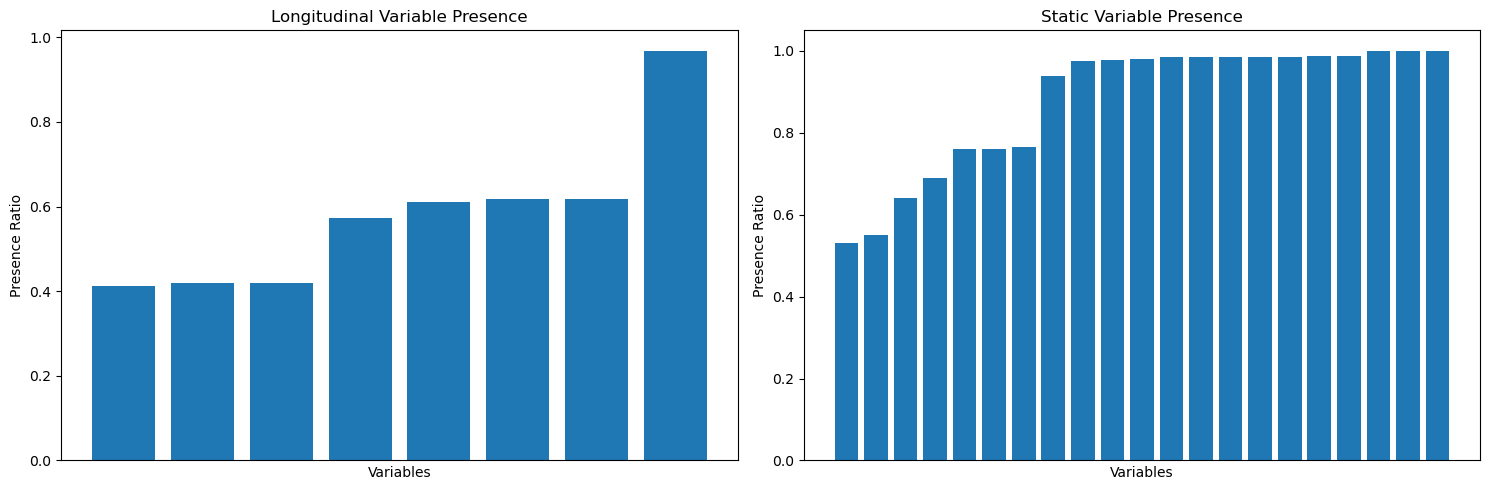

✅ Data processing completed successfully!


In [32]:
# Visualization
plt.figure(figsize=(15, 5))

# Longitudinal data presence
plt.subplot(1, 2, 1)
long_presence_sorted = long_presence.sort_values()
plt.bar(range(len(long_presence_sorted)), long_presence_sorted.values)
plt.title('Longitudinal Variable Presence')
plt.xlabel('Variables')
plt.ylabel('Presence Ratio')
plt.xticks([])

# Static data presence
plt.subplot(1, 2, 2)
static_presence_sorted = static_presence.sort_values()
plt.bar(range(len(static_presence_sorted)), static_presence_sorted.values)
plt.title('Static Variable Presence')
plt.xlabel('Variables')
plt.ylabel('Presence Ratio')
plt.xticks([])

plt.tight_layout()
plt.show()

print("✅ Data processing completed successfully!")

In [33]:
sns.set(style="whitegrid")

# ---- PARAMETERS ----
N_PATIENTS_SAMPLE = 10
N_PATIENTS_MISSING_HEATMAP = 50

# ---- LONGITUDINAL TRAJECTORIES ----
def plot_longitudinal_trajectories(df_long, vars=['psa']):
    sampled_patients = df_long['PATIENT_ID'].dropna().unique()[:N_PATIENTS_SAMPLE]
    df_subset = df_long[df_long['PATIENT_ID'].isin(sampled_patients)]

    for var in vars:
        if var in df_long.columns:
            plt.figure(figsize=(12, 5))
            sns.lineplot(data=df_subset, x='Time', y=var, hue='PATIENT_ID', marker="o", legend=False)
            plt.title(f"{var.upper()} Trajectories for {N_PATIENTS_SAMPLE} Patients")
            plt.xlabel("Date")
            plt.ylabel(var.upper())
            plt.xticks(rotation=45)
            plt.tight_layout()
            plt.show()

# ---- STATIC DISTRIBUTIONS ----
def plot_static_distributions(df_static, features=['Current Age', 'Sex', 'Stage (Highest Recorded)']):
    """
    Plot distributions of static features using Matplotlib subplots
    """
    n = len(features)
    plt.figure(figsize=(5 * n, 4))

    for i, feature in enumerate(features, 1):
        plt.subplot(1, n, i)
        if df_static[feature].nunique() < 10:
            counts = df_static[feature].value_counts()
            plt.bar(range(len(counts)), counts.values)
            plt.xticks(range(len(counts)), counts.index.astype(str), rotation=45)
            plt.ylabel('Count')
        else:
            plt.hist(df_static[feature].dropna(), bins=20, edgecolor='black', alpha=0.7)
            plt.ylabel('Frequency')
        plt.title(feature)
        plt.xlabel(feature)

    plt.tight_layout()
    plt.show()

# ---- MISSINGNESS (SIDE-BY-SIDE BAR PLOTS) ----
def plot_presence_side_by_side(df_long, df_static):
    """
    Bar plots of variable presence for longitudinal and static data
    """
    long_vars_to_analyze = [col for col in df_long.columns if col not in ['PATIENT_ID', 'Time']]
    long_presence = (~df_long[long_vars_to_analyze].isna()).mean().sort_values()
    static_presence = (~df_static.isna()).mean().sort_values()

    plt.figure(figsize=(15, 5))

    plt.subplot(1, 2, 1)
    plt.bar(range(len(long_presence)), long_presence.values)
    plt.title('Longitudinal Variable Presence')
    plt.xlabel('Variables')
    plt.ylabel('Presence Ratio')
    plt.xticks([])

    plt.subplot(1, 2, 2)
    plt.bar(range(len(static_presence)), static_presence.values)
    plt.title('Static Variable Presence')
    plt.xlabel('Variables')
    plt.ylabel('Presence Ratio')
    plt.xticks([])

    plt.tight_layout()
    plt.show()

    print("✅ Presence visualization completed successfully!")

def plot_missing_data_heatmap(df_long, df_static, max_vars=20):
    """
    Create heatmaps showing missing data patterns
    """
    fig, axes = plt.subplots(1, 2, figsize=(18, 5))
    
    # Longitudinal missing data heatmap
    long_missing = df_long.isna()
    long_vars_to_analyze = [col for col in df_long.columns if col not in ['PATIENT_ID', 'Time']]
    long_missing = long_missing[long_vars_to_analyze]
    long_missing_pct = long_missing.sum() / len(long_missing) * 100
    
    # Select top variables with most missing data
    top_long_vars = long_missing_pct.nlargest(max_vars).index
    long_subset = long_missing[top_long_vars]
    
    # Create patient-level missing pattern (sample of patients)
    sample_patients = df_long['PATIENT_ID'].unique()[:N_PATIENTS_MISSING_HEATMAP]
    long_patient_missing = long_subset[df_long['PATIENT_ID'].isin(sample_patients)]
    
    sns.heatmap(long_patient_missing.T, 
                cbar_kws={'label': 'Missing'}, 
                ax=axes[0], 
                cmap='Reds',
                yticklabels=True,
                xticklabels=False)
    axes[0].set_title('Longitudinal Data Missing Patterns (Sample Patients)')
    axes[0].set_ylabel('Variables')
    
    # Static missing data heatmap
    static_missing = df_static.isna()
    static_missing_pct = static_missing.sum() / len(static_missing) * 100
    
    # Select variables with missing data
    vars_with_missing = static_missing_pct[static_missing_pct > 0].index
    if len(vars_with_missing) > 0:
        static_subset = static_missing[vars_with_missing]
        sns.heatmap(static_subset.T, 
                    cbar_kws={'label': 'Missing'}, 
                    ax=axes[1], 
                    cmap='Reds',
                    yticklabels=True,
                    xticklabels=False)
        axes[1].set_title('Static Data Missing Patterns')
        axes[1].set_ylabel('Variables')
    
    plt.tight_layout()
    plt.show()

# ---- VISIT PATTERNS ----
def plot_patient_visit_summary(df_long):
    visits = df_long.groupby('PATIENT_ID')['Time'].count()
    plt.figure(figsize=(8, 4))
    plt.hist(visits, bins=20, edgecolor='black', alpha=0.7)
    plt.title("Distribution of Visits per Patient")
    plt.xlabel("Number of Visits")
    plt.ylabel("Patients")
    plt.tight_layout()
    plt.show()
    print(f"Avg visits: {visits.mean():.1f}, Max: {visits.max()}, Min: {visits.min()}")

# ---- CORRELATION ANALYSIS ----
def plot_correlation(df_static, df_long):
    """
    Plot correlation heatmap between static and longitudinal variables
    """
    # Get numeric static variables
    df_static_num = df_static.select_dtypes(include=np.number)
    
    # Get numeric longitudinal variables and compute patient means
    long_vars_to_analyze = [col for col in df_long.columns if col not in ['PATIENT_ID', 'Time']]
    df_long_num = df_long[long_vars_to_analyze].select_dtypes(include=np.number)
    
    if not df_long_num.empty:
        df_long_mean = df_long.groupby('PATIENT_ID')[df_long_num.columns].mean()
        
        # Combine static and longitudinal data
        df_combined = pd.merge(df_static_num, df_long_mean, 
                              left_index=True, right_index=True, how='inner')
        
        # Compute correlation
        corr = df_combined.corr()
        
        # Create mask for upper triangle
        mask = np.triu(np.ones_like(corr, dtype=bool))
        
        plt.figure(figsize=(12, 10))
        sns.heatmap(corr, mask=mask, cmap='coolwarm', center=0, square=True, 
                   annot=True, fmt='.2f', cbar_kws={'shrink': 0.8})
        plt.title("Correlation Heatmap: Static vs Longitudinal Variables")
        plt.tight_layout()
        plt.show()
    else:
        print("No numeric longitudinal variables found for correlation analysis")

# ---- DATA QUALITY DASHBOARD ----
def create_data_quality_dashboard(df_long, df_static):
    """
    Create a comprehensive data quality dashboard
    """
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    
    # 1. Longitudinal data presence
    long_vars_to_analyze = [col for col in df_long.columns if col not in ['PATIENT_ID', 'Time']]
    long_presence = (~df_long[long_vars_to_analyze].isna()).mean().sort_values()
    axes[0, 0].bar(range(len(long_presence)), long_presence.values)
    axes[0, 0].set_title('Longitudinal Variable Presence')
    axes[0, 0].set_ylabel('Presence Ratio')
    
    # 2. Static data presence
    static_presence = (~df_static.isna()).mean().sort_values()
    axes[0, 1].bar(range(len(static_presence)), static_presence.values)
    axes[0, 1].set_title('Static Variable Presence')
    axes[0, 1].set_ylabel('Presence Ratio')
    
    # 3. Visit distribution
    visits = df_long.groupby('PATIENT_ID')['Time'].count()
    axes[0, 2].hist(visits, bins=20, edgecolor='black', alpha=0.7)
    axes[0, 2].set_title('Visits per Patient')
    axes[0, 2].set_xlabel('Number of Visits')
    axes[0, 2].set_ylabel('Patients')
    
    # 4. Time span distribution
    time_spans = df_long.groupby('PATIENT_ID')['Time'].agg(['min', 'max'])
    time_spans['span'] = time_spans['max'] - time_spans['min']
    axes[1, 0].hist(time_spans['span'], bins=20, edgecolor='black', alpha=0.7)
    axes[1, 0].set_title('Patient Time Span')
    axes[1, 0].set_xlabel('Days')
    axes[1, 0].set_ylabel('Patients')
    
    # 5. Age distribution (if available)
    if 'Age' in df_static.columns:
        axes[1, 1].hist(df_static['Age'].dropna(), bins=20, edgecolor='black', alpha=0.7)
        axes[1, 1].set_title('Age Distribution')
        axes[1, 1].set_xlabel('Age')
        axes[1, 1].set_ylabel('Patients')
    else:
        axes[1, 1].text(0.5, 0.5, 'Age data not available', ha='center', va='center', transform=axes[1, 1].transAxes)
        axes[1, 1].set_title('Age Distribution')
    
    # 6. Cancer stage distribution (if available)
    if 'Height' in df_static.columns:
        stage_counts = df_static['Height'].value_counts()
        axes[1, 2].bar(range(len(stage_counts)), stage_counts.values)
        axes[1, 2].set_title('Height Distribution')
        axes[1, 2].set_xlabel('Height')
        axes[1, 2].set_ylabel('Patients')
        axes[1, 2].set_xticks(range(len(stage_counts)))
        axes[1, 2].set_xticklabels(stage_counts.index, rotation=45)
    else:
        axes[1, 2].text(0.5, 0.5, 'Height data not available', ha='center', va='center', transform=axes[1, 2].transAxes)
        axes[1, 2].set_title('Height Distribution')
    
    plt.tight_layout()
    plt.show()
    
    # Print summary statistics
    print("=== DATA QUALITY SUMMARY ===")
    print(f"Total patients: {df_static.shape[0]}")
    print(f"Longitudinal records: {len(df_long)}")
    print(f"Longitudinal variables: {len(long_vars_to_analyze)}")
    print(f"Static variables: {df_static.shape[1]}")
    print(f"Average visits per patient: {visits.mean():.1f}")
    print(f"Time span range: {time_spans['span'].min():.0f} to {time_spans['span'].max():.0f} days")

# ---- WRAPPER ----
def analyze_physionet_data(df_long, df_static):
    """
    Comprehensive analysis of Physionet 2012 data
    """
    print("📈 Longitudinal trajectories...")
    plot_longitudinal_trajectories(df_long, vars=["HR", 'NIDiasABP', 'NIMAP', 'NISysABP', 'Urine', 'DiasABP', 'MAP', 'SysABP'])

    print("📊 Static feature distributions...")
    plot_static_distributions(df_static, features=["Age", "Gender",	'Height', "ICUType", "Weight", "BUN", "Creatinine"])

    print("�� Presence bar plots...")
    plot_presence_side_by_side(df_long, df_static)
    
    print("🔥 Missing data heatmaps...")
    plot_missing_data_heatmap(df_long, df_static, max_vars=20)

    print("📅 Visit patterns...")
    plot_patient_visit_summary(df_long)
    
    print("📊 Data quality dashboard...")
    create_data_quality_dashboard(df_long, df_static)
    
    print("✅ Physionet 2012 data analysis completed!")

📈 Longitudinal trajectories...


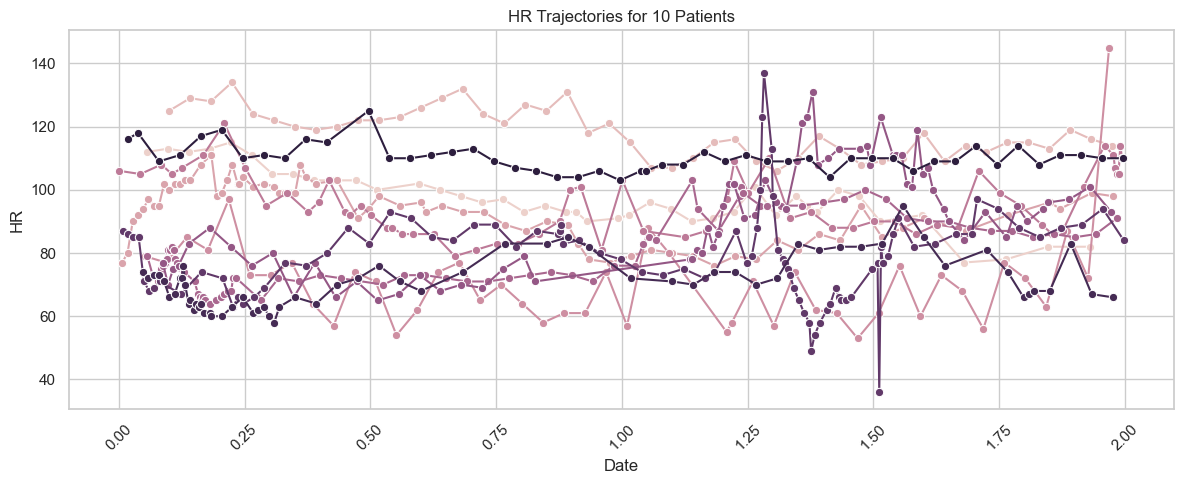

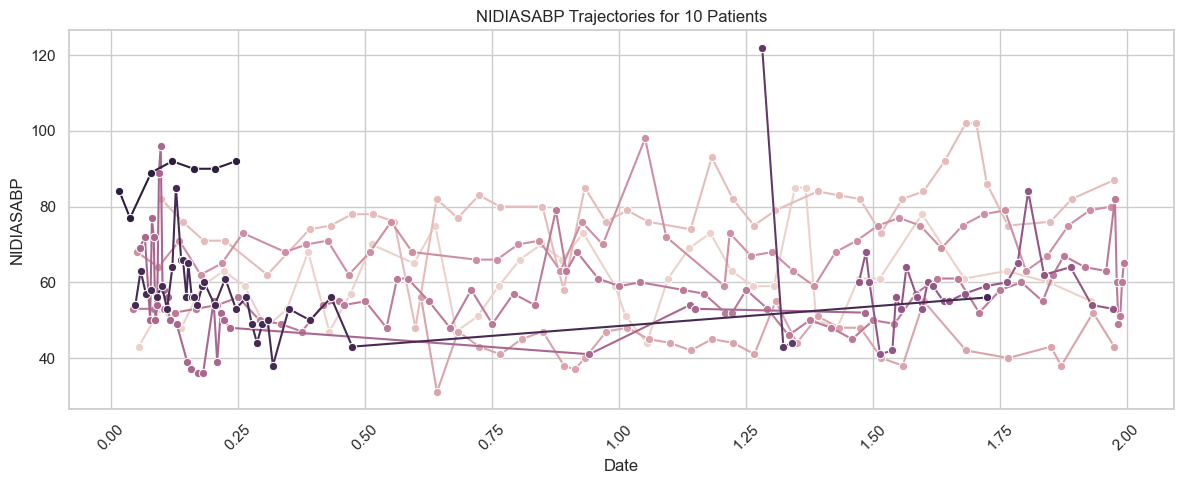

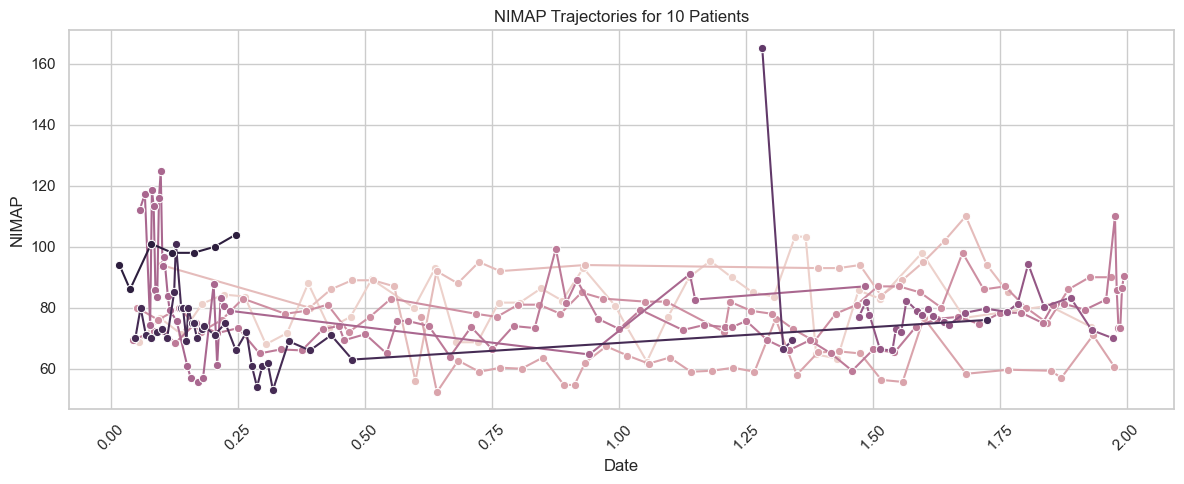

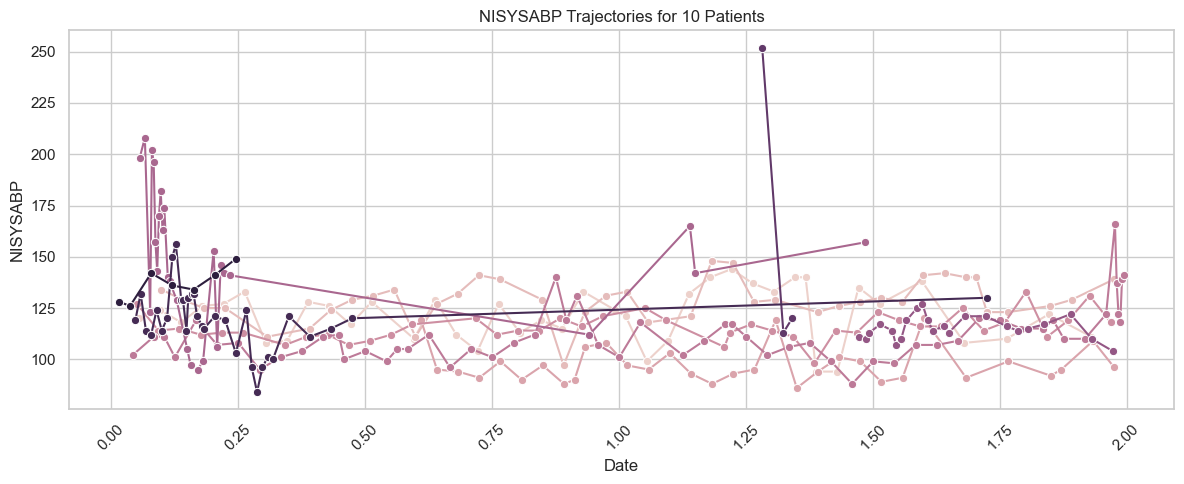

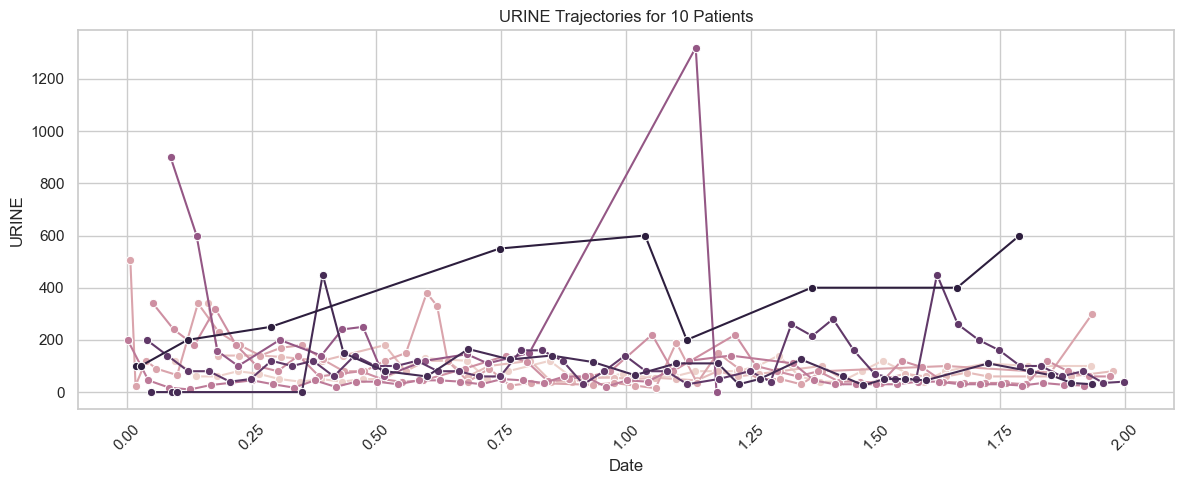

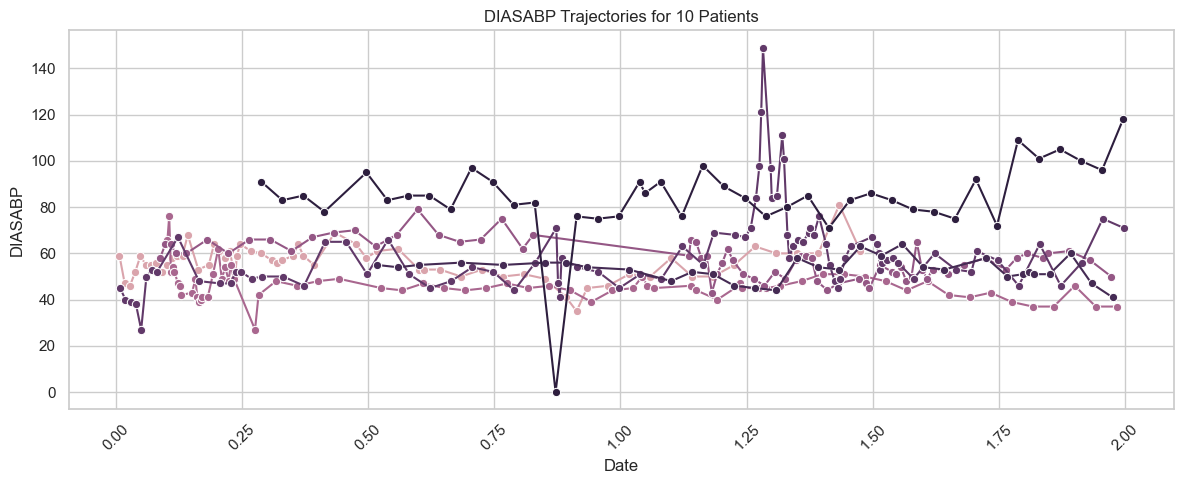

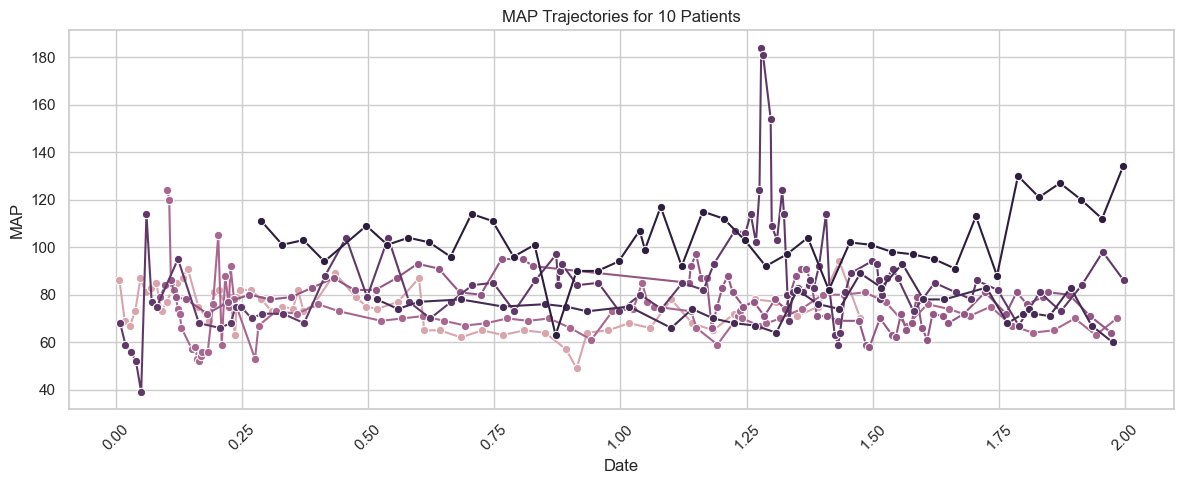

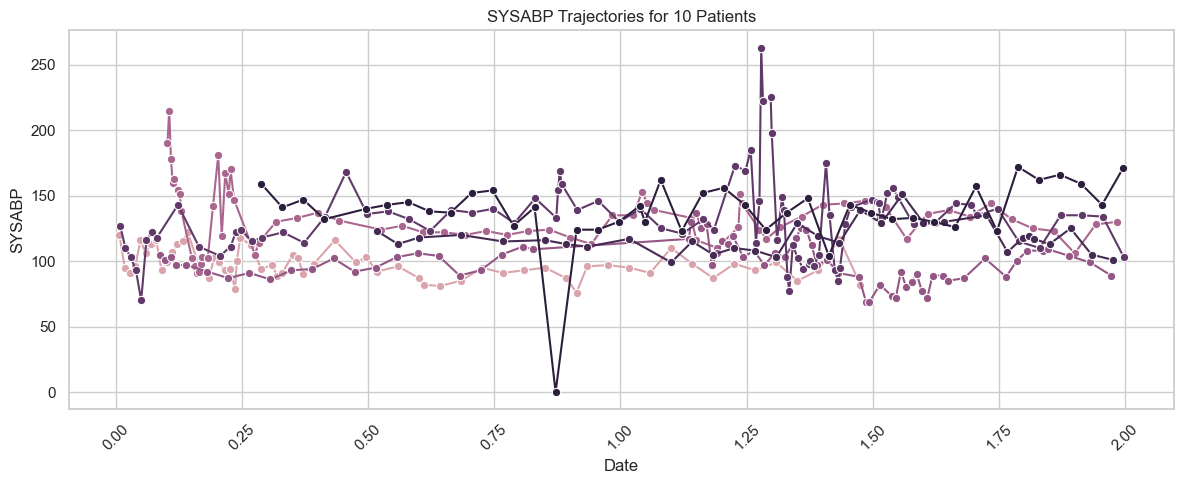

📊 Static feature distributions...


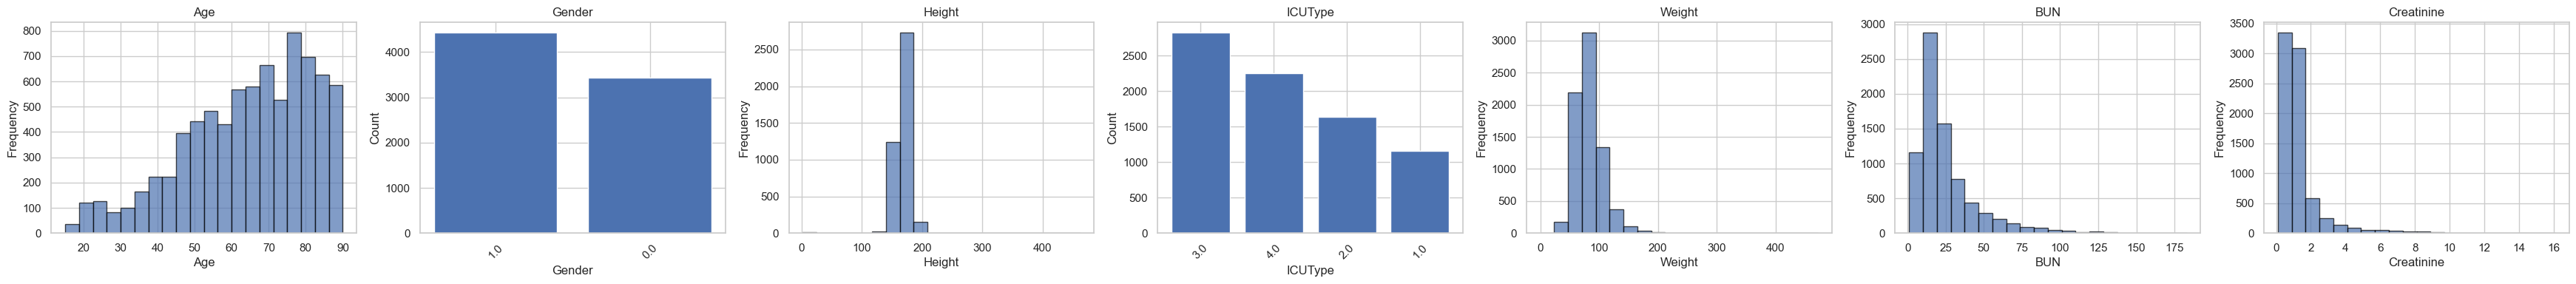

�� Presence bar plots...


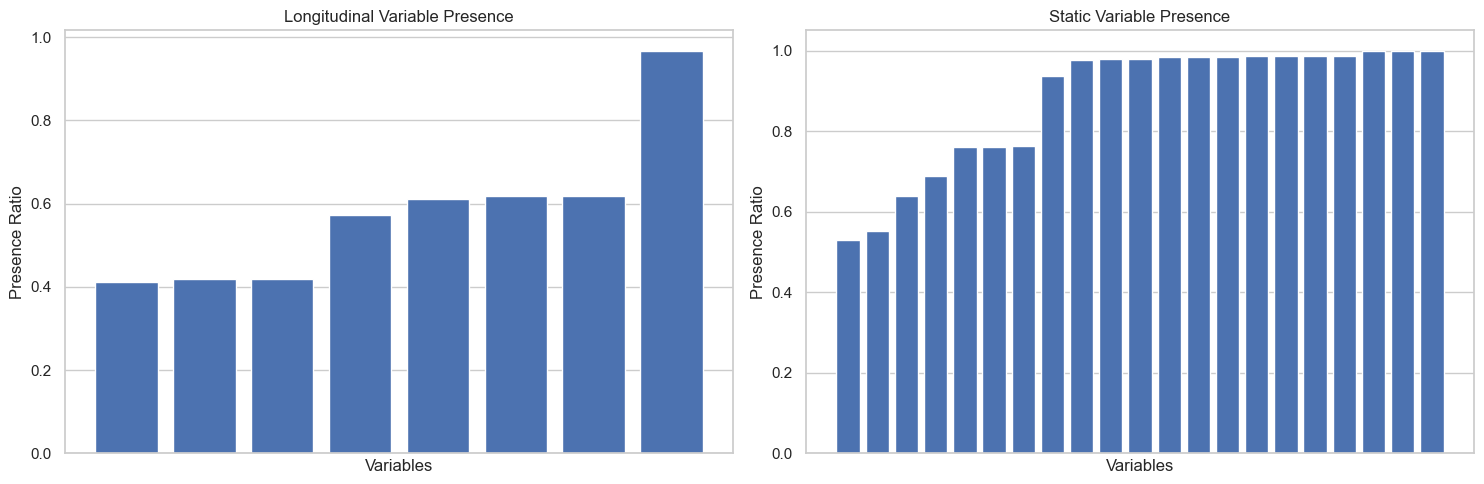

✅ Presence visualization completed successfully!
🔥 Missing data heatmaps...


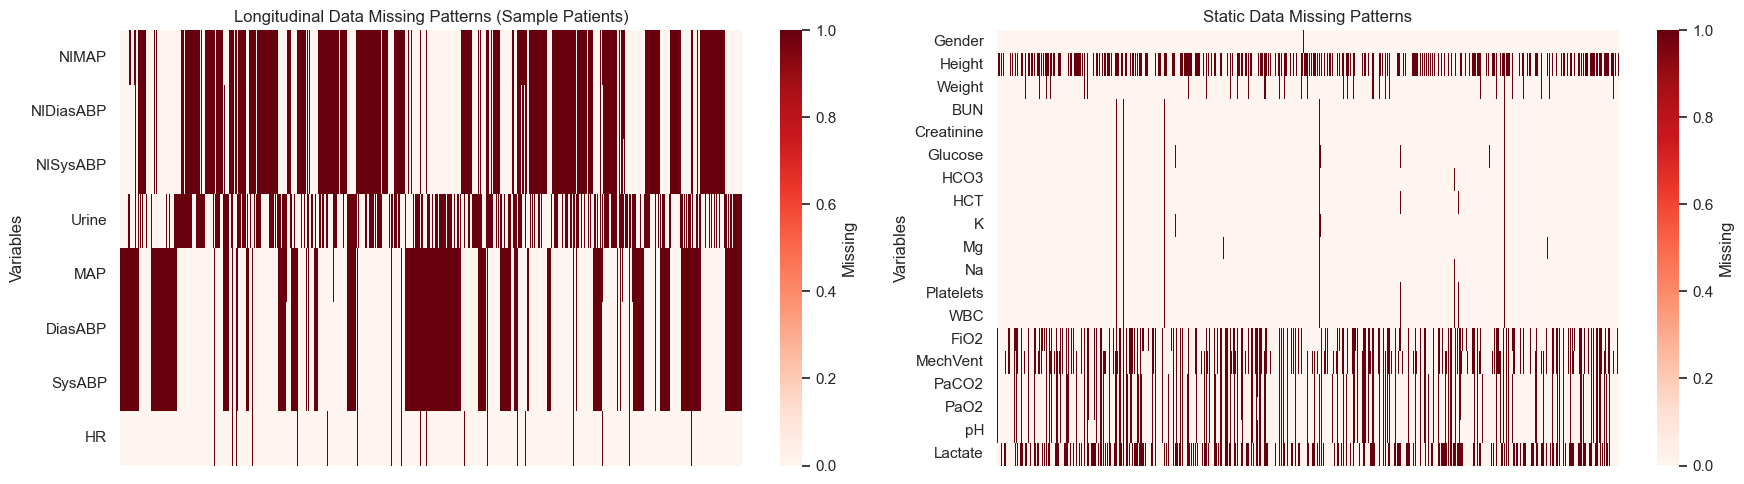

📅 Visit patterns...


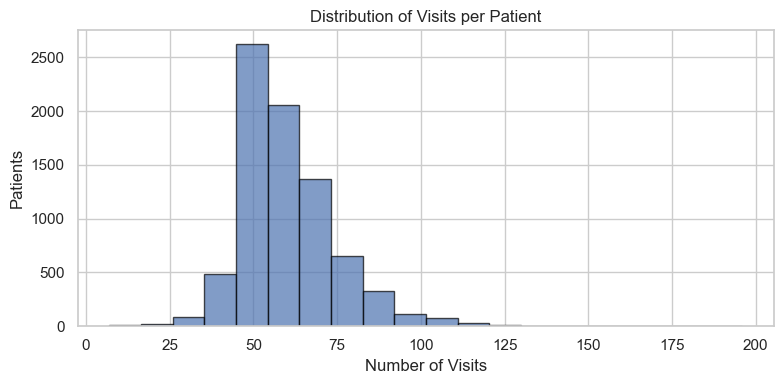

Avg visits: 60.0, Max: 196, Min: 7
📊 Data quality dashboard...


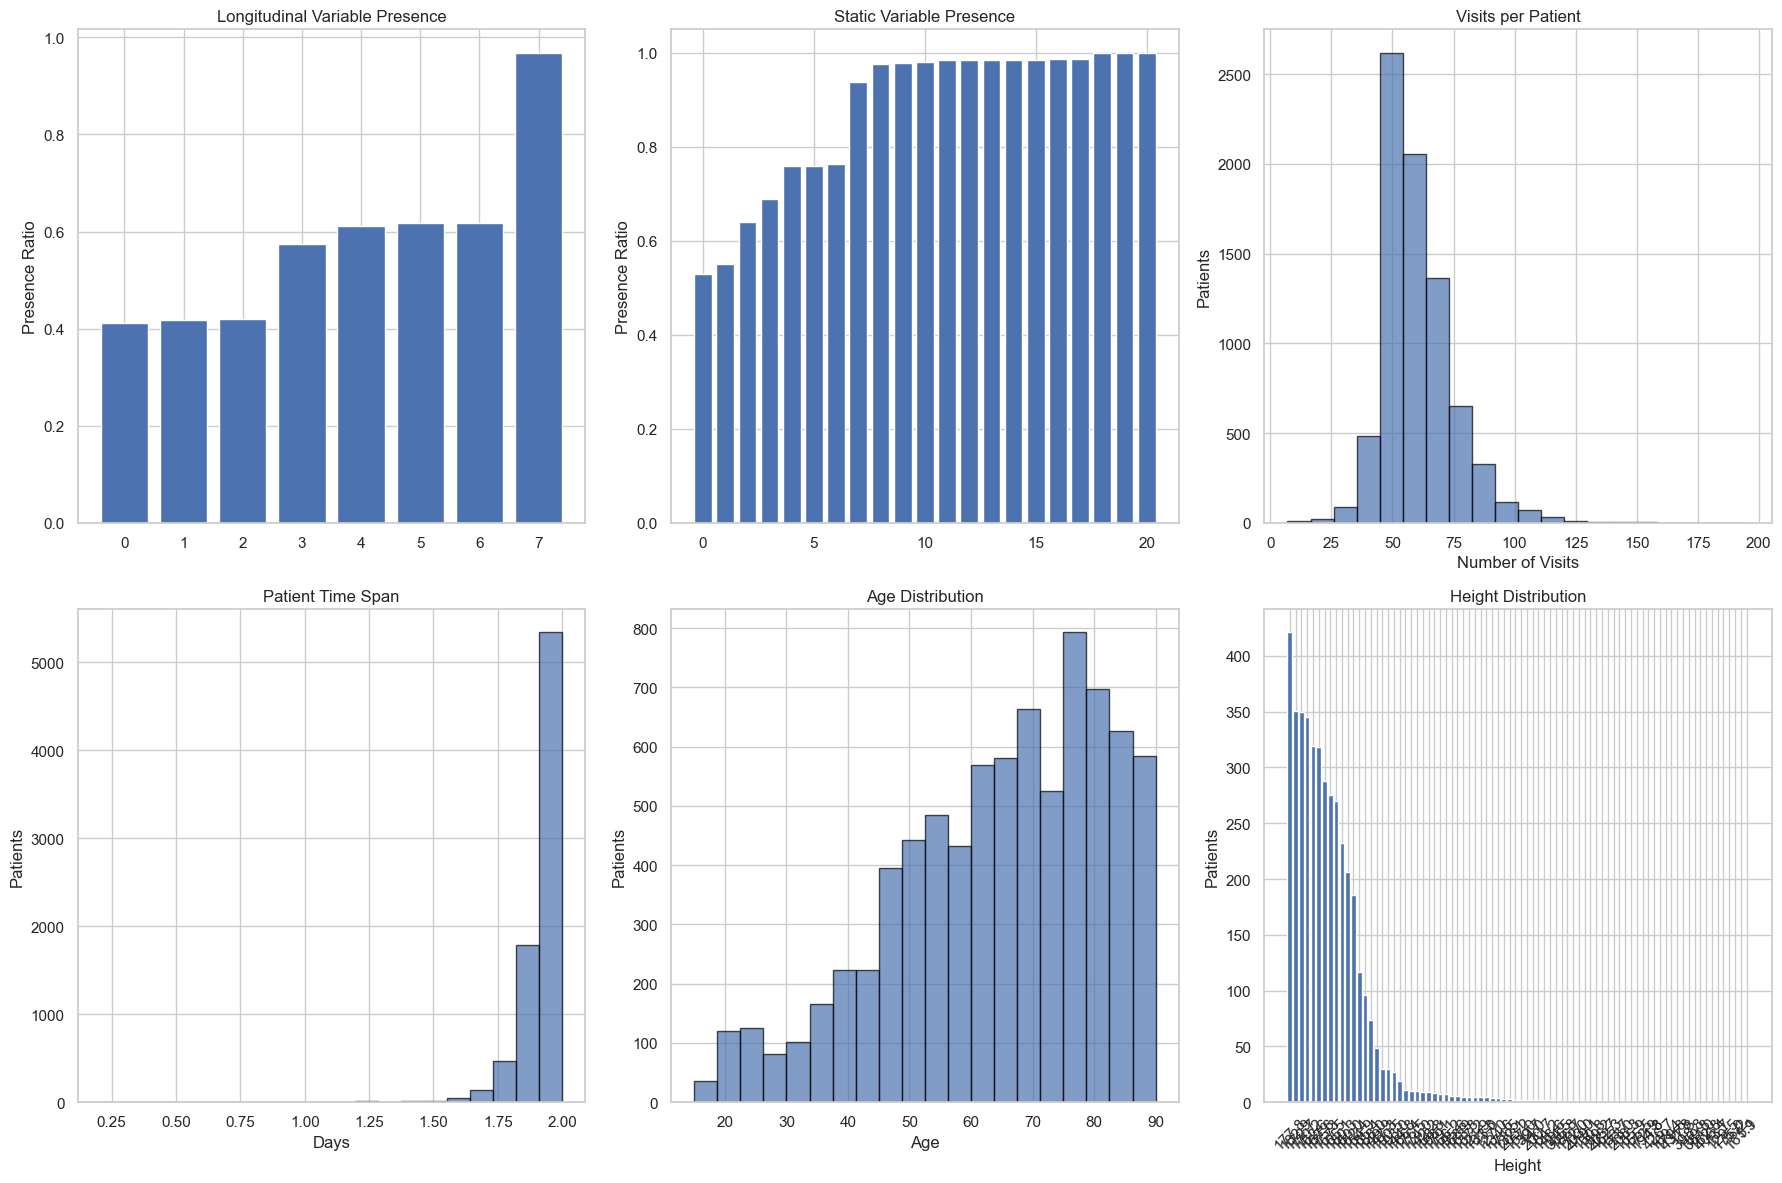

=== DATA QUALITY SUMMARY ===
Total patients: 7871
Longitudinal records: 472225
Longitudinal variables: 8
Static variables: 21
Average visits per patient: 60.0
Time span range: 0 to 2 days
✅ Physionet 2012 data analysis completed!


In [34]:
analyze_physionet_data(df_long_final, df_static_final)